In [1]:
pip install diffusers transformers accelerate torch torchvision safetensors


   ---------------------------------------- 0.0/4.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.6 MB 2.6 MB/s eta 0:00:02
   --------- ------------------------------ 1.0/4.6 MB 2.1 MB/s eta 0:00:02
   --------------- ------------------------ 1.8/4.6 MB 3.0 MB/s eta 0:00:01
   ----------------------------- ---------- 3.4/4.6 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 4.6/4.6 MB 4.7 MB/s  0:00:01
   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ------------ --------------------------- 1.3/4.2 MB 6.3 MB/s eta 0:00:01
   ---------------------- ----------------- 2.4/4.2 MB 7.2 MB/s eta 0:00:01
   ------------------------ --------------- 2.6/4.2 MB 6.0 MB/s eta 0:00:01
   ------------------------ --------------- 2.6/4.2 MB 6.0 MB/s eta 0:00:01
   ------------------------------------- --


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
from diffusers import StableDiffusionPipeline, EulerAncestralDiscreteScheduler

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(
    model_id, torch_dtype=torch.float16 if device=="cuda" else torch.float32
)

pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)

if device == "cuda":
    pipe = pipe.to(device)
    pipe.enable_attention_slicing()
else:
    pipe.to(device)

c:\Users\HP ELITE BOOK\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\HP ELITE BOOK\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\amp\autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
c:\Users\HP ELITE BOOK\AppData\Local\Programs\Python\Python314\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP ELITE BOOK\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting th

In [3]:
prompt = "ultra-detailed portrait of a red fox wearing a tiny scarf, cinematic lighting, 35mm"
negative_prompt = "blurry, lowres, jpeg artifacts, extra fingers, text, watermark"

In [4]:
image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,   # 20–35 is a good range
    guidance_scale=7.5,       # 5–9 usually
    height=512,
    width=512,
    generator=torch.Generator(device=device).manual_seed(42)
).images[0]

image.save("generated_image.png")

100%|██████████| 30/30 [14:22<00:00, 28.76s/it]


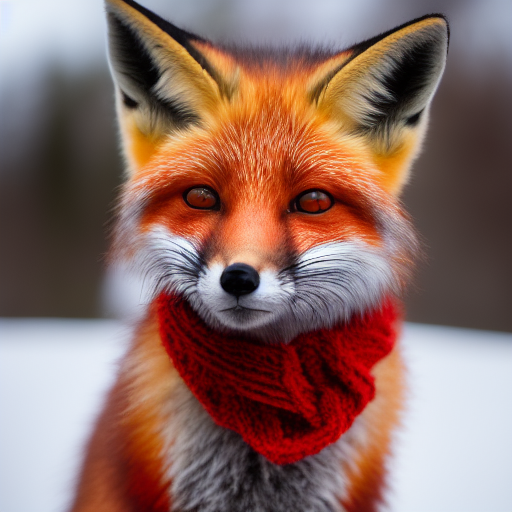

In [5]:
from IPython.display import display
display(image)